# DINOv2 vs DINOv3 visualizations on OUR OWN dataset

This notebook makes **paper-ready figures** comparing the two backbones, using our own
Unitree Go2 recordings (not RELLIS). Every figure is produced by its own cell and saved as a
PNG, so you can run them, look at the results, and pick whichever ones you want to include.

| Figure | Cell | What it shows |
|---|---|---|
| **A** | §3 | The whole pipeline for one frame: image → path overlay → SLIC → DINOv2 → DINOv3 → training input |
| **B** | §4 | The averaging step: one flat colour per superpixel, both backbones |
| **C** | §5 | Feature maps side by side across several frames (are the two backbones consistent?) |
| **D** | §6 | Similarity maps: pick a point, see what each backbone thinks looks the same |
| **E** | §7 | Traversability cost from our own-trained autoencoders, plus STEPP-style green/red |
| **F** | §8 | Patch-resolution difference: 50×50 (DINOv2) vs 44×44 (DINOv3), zoomed |
| **G** | §9 | Feature-statistics comparison (why the two cost scales are not comparable) |

All figures are written to `own_outputs/paper_figures/`.

## 1. Settings

In [62]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Own_dataset')
OWN_OUT   = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/own_outputs')
MODEL_DIR = OWN_OUT / 'models'
FIG_DIR   = OWN_OUT / 'paper_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DINOV3_REPO    = Path('C:/Users/jthre/.cache/torch/hub/facebookresearch_dinov3_main')
DINOV3_WEIGHTS = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/DinoV3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth')

# ---- which frame is the "hero" frame used by figures A, B, D, E, F ----
MAIN_SEQ   = '00009'
MAIN_FRAME = 700          # index into that sequence's image list

# ---- extra frames used by figure C (one per entry) ----
EXTRA_FRAMES = [('00003', 400), ('00007', 700), ('00010', 800)]

# ---- path-projection settings (identical to process_own_dataset.ipynb) ----
FUTURE_STEPS    = 50
MIN_Z           = 0.5
GROUND_OFFSET_M = 0.35
ROBOT_WIDTH_M   = 0.40

N_SEGMENTS   = 400
COMPACTNESS  = 15
HIDDEN_SIZES = [256, 128, 64, 32, 64, 128, 256]

SAVE_DPI = 200            # good enough for print in a two-column paper

# one fixed colour per backbone, used consistently in every chart
COLOUR = {'dinov2': '#1f77b4', 'dinov3': '#d95f02'}

print('figures will be saved to:', FIG_DIR)

figures will be saved to: s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures


## 2. Imports, backbones, autoencoders and helper functions

In [63]:
import sys, warnings; warnings.filterwarnings('ignore')
import numpy as np
import cv2
import yaml
import torch
import torch.nn as nn
from torchvision import transforms
from scipy.spatial.transform import Rotation
from skimage.segmentation import slic, mark_boundaries
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
print('device:', device)

BACKBONES = ['dinov2', 'dinov3']

def load_backbone(name):
    if name == 'dinov2':
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
        input_size, patch = 700, 14
    else:
        sys.path.insert(0, str(DINOV3_REPO))
        from dinov3.hub.backbones import dinov3_vits16
        model = dinov3_vits16(weights=str(DINOV3_WEIGHTS))
        input_size, patch = 704, 16
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad = False
    return model, input_size, patch, input_size // patch

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []; current = input_dim
        for size in hidden_sizes:
            layers += [nn.Linear(current, size), nn.ReLU()]; current = size
        layers.append(nn.Linear(current, input_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def load_autoencoder(name):
    model = Autoencoder(384, HIDDEN_SIZES).to(device)
    model.load_state_dict(torch.load(MODEL_DIR / f'own_autoencoder_{name}.pth',
                                     map_location=device))
    model.eval()
    return model

def feature_map(model, square_rgb, grid):
    """square RGB picture -> (grid, grid, 384) numpy array."""
    x = torch.from_numpy(square_rgb).permute(2, 0, 1).float() / 255.0
    x = normalize(x).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = model.get_intermediate_layers(x, n=1)[0][0]
    return tokens.reshape(grid, grid, 384).cpu().numpy()

def pca_colours(features_2d, fitted_pca=None):
    """(N, 384) -> (N, 3) colours in 0..1. Pass a fitted PCA to reuse the same colours."""
    if fitted_pca is None:
        fitted_pca = PCA(n_components=3).fit(features_2d)
    compressed = fitted_pca.transform(features_2d)
    low  = np.percentile(compressed, 2, axis=0)
    high = np.percentile(compressed, 98, axis=0)
    return np.clip((compressed - low) / (high - low + 1e-9), 0, 1), fitted_pca

def run_slic(square_rgb):
    return slic(square_rgb, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                start_label=0, channel_axis=-1)

def save(fig_name):
    path = FIG_DIR / fig_name
    plt.savefig(path, dpi=SAVE_DPI, bbox_inches='tight')
    print('saved ->', path)

device: cuda


In [64]:
# ---- loading a sequence and projecting the future path (same maths as before) ----
def load_sequence(seq):
    seq_dir = DATA_ROOT / seq
    image_paths = sorted((seq_dir / 'pylon_camera_node').glob('*.jpg'))
    pose_lines = [l for l in (seq_dir / 'poses.txt').read_text().splitlines() if l.strip()]

    poses = []
    for line in pose_lines:
        T = np.eye(4)
        T[:3, :4] = np.array(line.split(), dtype=np.float64).reshape(3, 4)
        poses.append(T)
    T_body = np.stack(poses)

    fx, fy, cx, cy = np.loadtxt(seq_dir / 'camera_info.txt').ravel()[:4]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)

    tf = yaml.safe_load((seq_dir / 'transforms.yaml').read_text())
    key = next(k for k in tf if 'os1' in k and 'pylon' in k)
    q, t = tf[key]['q'], tf[key]['t']
    T_yaml = np.eye(4)
    T_yaml[:3, :3] = Rotation.from_quat([q['x'], q['y'], q['z'], q['w']]).as_matrix()
    T_yaml[:3, 3] = [t['x'], t['y'], t['z']]

    height, width = cv2.imread(str(image_paths[0])).shape[:2]
    return {'images': image_paths, 'T_body': T_body, 'T_cam': T_body @ T_yaml,
            'K': K, 'width': width, 'height': height}

def path_mask(data, idx):
    """Binary mask of the ground the robot walks over next, seen from frame idx."""
    T_body, T_cam, K = data['T_body'], data['T_cam'], data['K']
    width, height = data['width'], data['height']
    left_edge, right_edge = [], []
    for j in range(idx + 1, min(idx + 1 + FUTURE_STEPS, len(T_body))):
        position = T_body[j][:3, 3]
        forward = T_body[j][:3, 0].copy(); forward[2] = 0.0
        length = np.linalg.norm(forward)
        if length < 1e-6:
            continue
        forward /= length
        left = np.array([-forward[1], forward[0], 0.0])
        ground = position - np.array([0.0, 0.0, GROUND_OFFSET_M])
        left_edge.append(ground + 0.5 * ROBOT_WIDTH_M * left)
        right_edge.append(ground - 0.5 * ROBOT_WIDTH_M * left)

    mask = np.zeros((height, width), np.uint8)
    centreline = np.zeros((0, 2))
    if len(left_edge) < 2:
        return mask, centreline

    def to_pixels(points):
        world_to_cam = np.linalg.inv(T_cam[idx])
        pts = np.array(points) @ world_to_cam[:3, :3].T + world_to_cam[:3, 3]
        visible = pts[:, 2] > MIN_Z
        pixels = np.full((len(points), 2), np.nan)
        if visible.any():
            proj, _ = cv2.projectPoints(pts[visible].reshape(-1, 1, 3),
                                        np.zeros(3), np.zeros(3), K, np.zeros(5))
            pixels[visible] = proj.reshape(-1, 2)
        return pixels, visible

    pix_left, vis_left = to_pixels(left_edge)
    pix_right, vis_right = to_pixels(right_edge)
    centre = (np.array(left_edge) + np.array(right_edge)) / 2
    pix_centre, vis_centre = to_pixels(centre)
    centreline = pix_centre[vis_centre]

    for j in range(len(left_edge) - 1):
        if not (vis_left[j] and vis_right[j] and vis_left[j + 1] and vis_right[j + 1]):
            continue
        quad = np.clip(np.array([pix_left[j], pix_left[j + 1],
                                 pix_right[j + 1], pix_right[j]]), -3e4, 3e4).astype(np.int32)
        if quad[:, 0].max() < 0 or quad[:, 0].min() >= width:
            continue
        if quad[:, 1].max() < 0 or quad[:, 1].min() >= height:
            continue
        cv2.fillPoly(mask, [quad], 1)
    return mask, centreline

def overlay_path(bgr, mask, centreline):
    out = bgr.copy()
    ribbon = mask > 0
    out[ribbon] = (0.45 * out[ribbon] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    height, width = bgr.shape[:2]
    inside = centreline[np.all((centreline >= 0) & (centreline < [width, height]), axis=1)]
    if len(inside) >= 2:
        cv2.polylines(out, [inside.astype(np.int32)], False, (0, 0, 255), 3)
    return out

# load the sequences we need and pick the hero frame
sequences = {MAIN_SEQ: load_sequence(MAIN_SEQ)}
for seq, _ in EXTRA_FRAMES:
    if seq not in sequences:
        sequences[seq] = load_sequence(seq)

main_data = sequences[MAIN_SEQ]
MAIN_FRAME = min(MAIN_FRAME, len(main_data['images']) - FUTURE_STEPS - 1)
hero_bgr = cv2.imread(str(main_data['images'][MAIN_FRAME]))
hero_rgb = cv2.cvtColor(hero_bgr, cv2.COLOR_BGR2RGB)
hero_mask, hero_centreline = path_mask(main_data, MAIN_FRAME)
print(f'hero frame: {MAIN_SEQ} / {main_data["images"][MAIN_FRAME].name}  '
      f'({int(hero_mask.sum())} path pixels)')

hero frame: 00009 / frame000700-1786115190_689.jpg  (15152 path pixels)


In [65]:
# ---- compute everything both backbones need for the hero frame, once ----
hero = {}
for name in BACKBONES:
    model, input_size, patch, grid = load_backbone(name)
    autoencoder = load_autoencoder(name)

    square = cv2.resize(hero_rgb, (input_size, input_size))
    segments = run_slic(square)
    small_mask = cv2.resize(hero_mask, (input_size, input_size),
                            interpolation=cv2.INTER_NEAREST)
    path_ids = np.unique(segments[small_mask > 0])

    features = feature_map(model, square, grid)
    small_segments = cv2.resize(segments.astype(np.int32), (grid, grid),
                                interpolation=cv2.INTER_NEAREST)

    # one averaged vector per superpixel
    ids, vectors = [], []
    for sid in np.unique(small_segments):
        cells = small_segments == sid
        if cells.sum() > 0:
            vectors.append(features[cells].mean(axis=0)); ids.append(sid)
    vectors = np.array(vectors, dtype=np.float32)

    # reconstruction cost per superpixel
    with torch.no_grad():
        x = torch.from_numpy(vectors).to(device)
        costs = ((x - autoencoder(x)) ** 2).mean(dim=1).cpu().numpy()

    hero[name] = {'model_input': input_size, 'patch': patch, 'grid': grid,
                  'square': square, 'segments': segments, 'path_ids': path_ids,
                  'features': features, 'small_segments': small_segments,
                  'ids': ids, 'vectors': vectors, 'costs': costs}
    print(f'{name}: grid {grid}x{grid}, {len(ids)} superpixels, '
          f'{len(path_ids)} on the path, feature std {features.std():.3f}')

    del model, autoencoder
    torch.cuda.empty_cache()

dinov2: grid 50x50, 332 superpixels, 42 on the path, feature std 2.534
dinov3: grid 44x44, 329 superpixels, 41 on the path, feature std 0.386


## 3. Figure A --- the whole pipeline on one frame

The same layout as the RELLIS pipeline figure, but on our own data: original image, projected
path, SLIC superpixels with the path ones highlighted, both feature maps as colours, and
finally the region that actually becomes training data.

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figA_pipeline_own.png


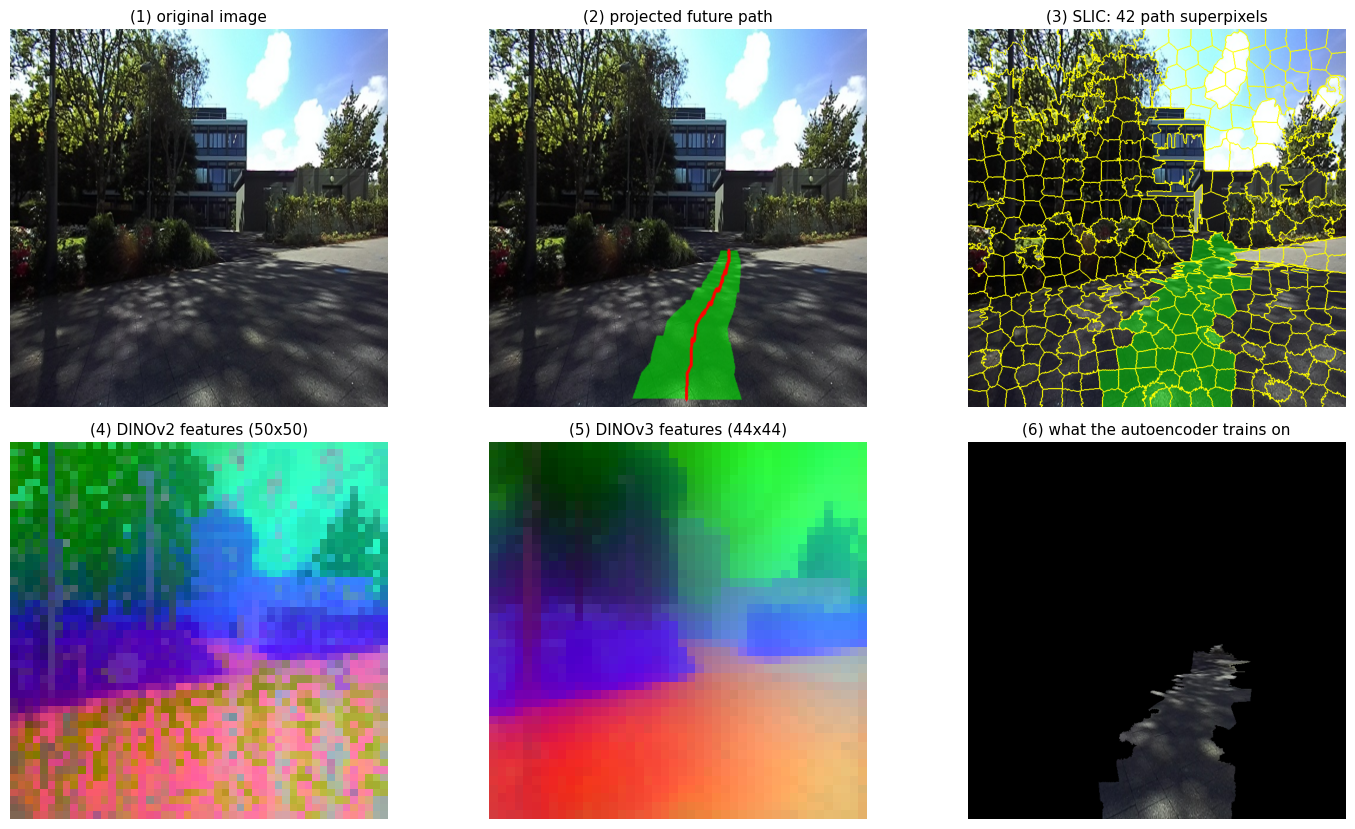

In [66]:
size2 = hero['dinov2']['model_input']
square2 = hero['dinov2']['square']
segments2 = hero['dinov2']['segments']
on_path2 = np.isin(segments2, hero['dinov2']['path_ids'])

# 3) SLIC picture with path superpixels tinted green
slic_pic = square2.copy()
slic_pic[on_path2] = (0.55 * slic_pic[on_path2] + 0.45 * np.array([0, 255, 0])).astype(np.uint8)
slic_pic = (mark_boundaries(slic_pic, segments2, color=(1, 1, 0)) * 255).astype(np.uint8)

# 4/5) feature maps as PCA colours
pca_pics = {}
for name in BACKBONES:
    f = hero[name]['features']
    colours, _ = pca_colours(f.reshape(-1, 384))
    pca_pics[name] = colours.reshape(f.shape[0], f.shape[1], 3)

# 6) training input: only the path superpixels stay visible
training_input = square2.copy()
training_input[~on_path2] = 0

# panels 1-2 are resized to the same square the pipeline actually works on,
# so that all six panels share one shape and the grid lines up
overlay_rgb = cv2.cvtColor(overlay_path(hero_bgr, hero_mask, hero_centreline),
                           cv2.COLOR_BGR2RGB)
panels = [
    (cv2.resize(hero_rgb, (size2, size2)),         '(1) original image'),
    (cv2.resize(overlay_rgb, (size2, size2)),      '(2) projected future path'),
    (slic_pic,        f'(3) SLIC: {len(hero["dinov2"]["path_ids"])} path superpixels'),
    (pca_pics['dinov2'], f'(4) DINOv2 features ({hero["dinov2"]["grid"]}x{hero["dinov2"]["grid"]})'),
    (pca_pics['dinov3'], f'(5) DINOv3 features ({hero["dinov3"]["grid"]}x{hero["dinov3"]["grid"]})'),
    (training_input,                               '(6) what the autoencoder trains on'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.4))
for ax, (picture, title) in zip(axes.ravel(), panels):
    ax.imshow(picture)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
save('figA_pipeline_own.png')
plt.show()

## 4. Figure B --- the averaging step, both backbones

Each superpixel is filled with **one flat colour** made from its averaged 384-number vector.
One flat patch equals one row of training data. The right-hand column keeps only the
superpixels the robot walked over.

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figB_segment_average_own.png


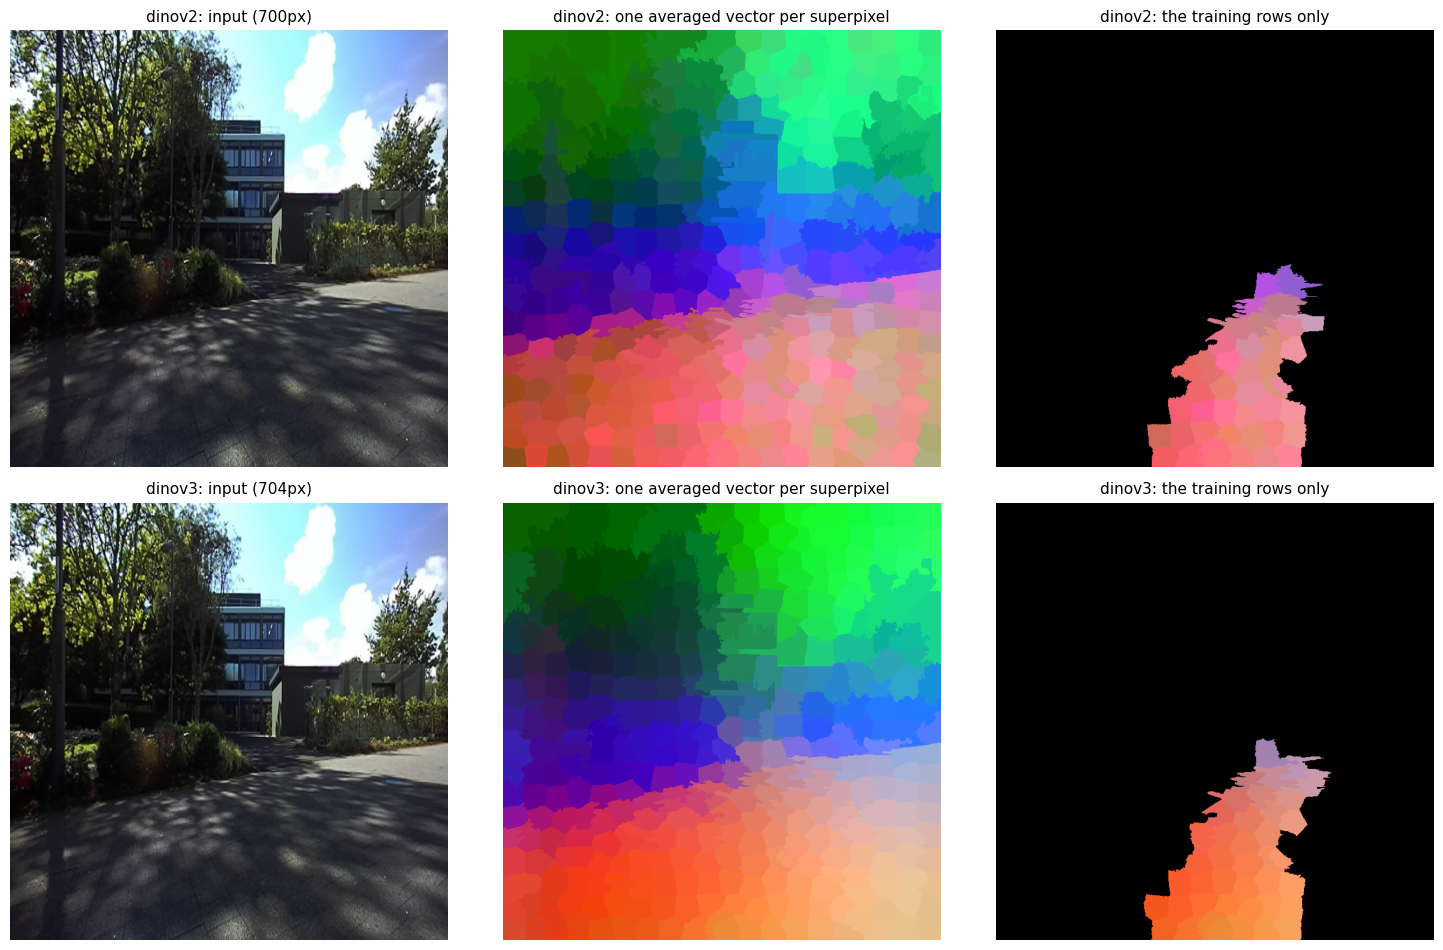

In [67]:
def paint_segments(name, only_path=False):
    h = hero[name]
    colours, _ = pca_colours(h['vectors'])
    size = h['model_input']
    picture = np.zeros((size, size, 3))
    for sid, colour in zip(h['ids'], colours):
        picture[h['segments'] == sid] = colour
    if only_path:
        picture[~np.isin(h['segments'], h['path_ids'])] = 0
    return picture

fig, axes = plt.subplots(2, 3, figsize=(15, 9.6))
for row, name in enumerate(BACKBONES):
    axes[row, 0].imshow(hero[name]['square'])
    axes[row, 0].set_title(f'{name}: input ({hero[name]["model_input"]}px)', fontsize=11)
    axes[row, 1].imshow(paint_segments(name))
    axes[row, 1].set_title(f'{name}: one averaged vector per superpixel', fontsize=11)
    axes[row, 2].imshow(paint_segments(name, only_path=True))
    axes[row, 2].set_title(f'{name}: the training rows only', fontsize=11)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
save('figB_segment_average_own.png')
plt.show()

## 5. Figure C --- feature maps across several frames

The PCA is fitted on the first frame and **reused** for the others, so colours mean the same
thing in every column. If a backbone is consistent, the same terrain keeps the same colour
across different places and lighting.

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figC_features_across_frames.png


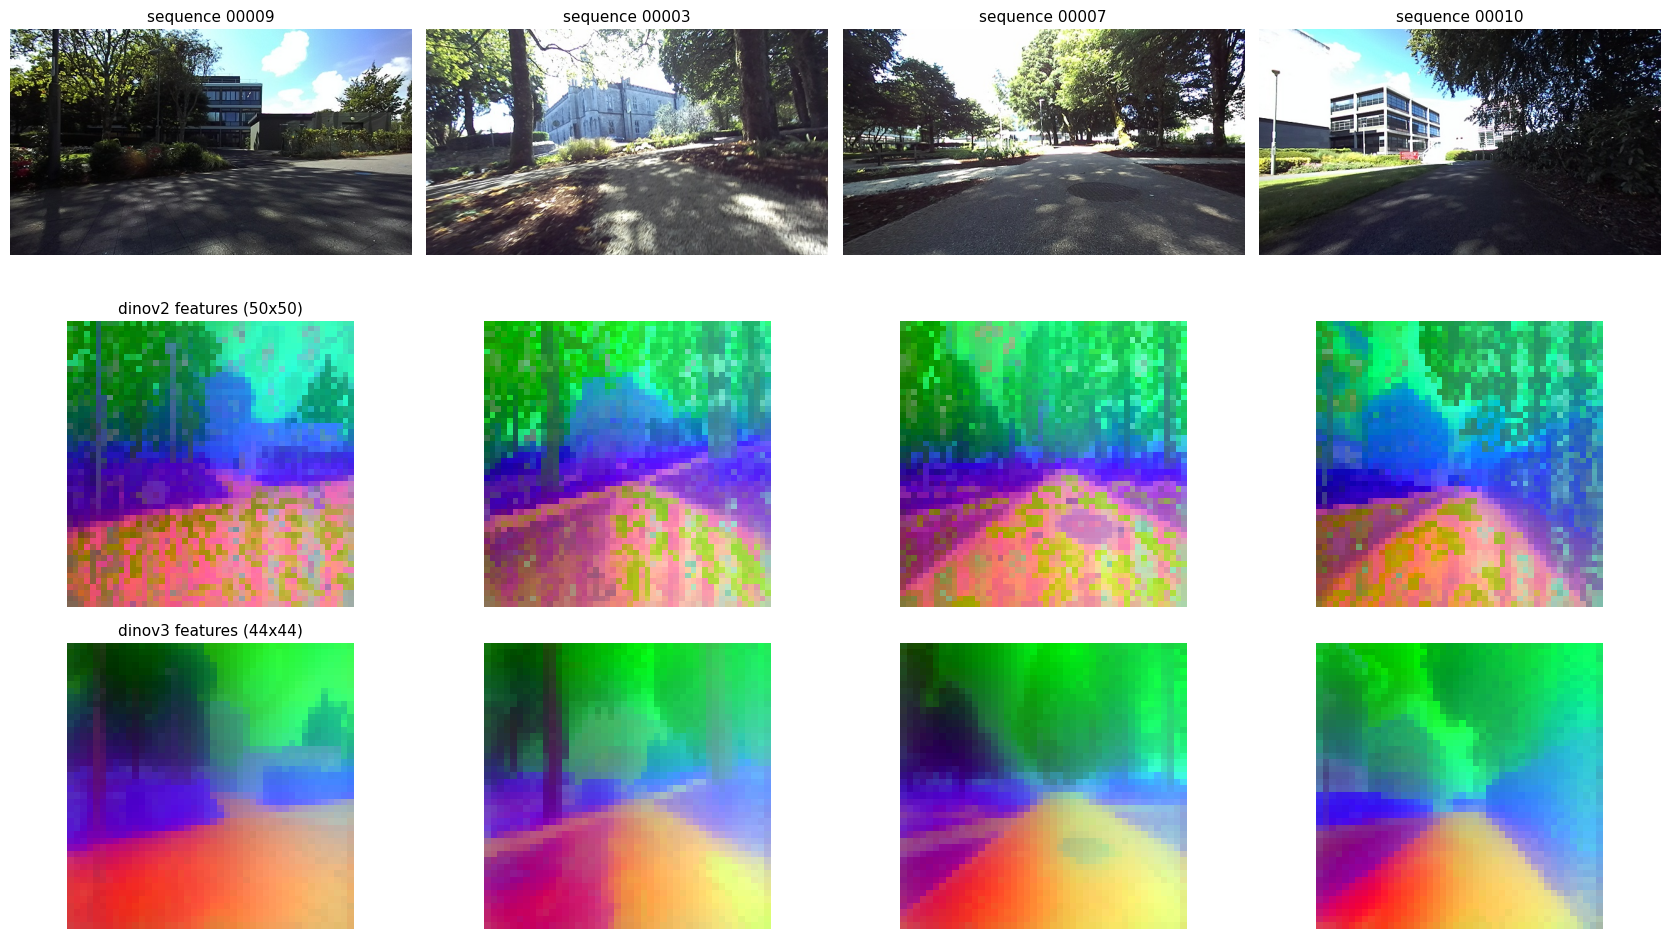

In [68]:
frame_list = [(MAIN_SEQ, MAIN_FRAME)] + EXTRA_FRAMES

# collect the images first
chosen = []
for seq, idx in frame_list:
    data = sequences[seq]
    idx = min(idx, len(data['images']) - 1)
    bgr = cv2.imread(str(data['images'][idx]))
    chosen.append((seq, cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))

fig, axes = plt.subplots(3, len(chosen), figsize=(4.2 * len(chosen), 9.6))
for column, (seq, rgb) in enumerate(chosen):
    axes[0, column].imshow(rgb)
    axes[0, column].set_title(f'sequence {seq}', fontsize=11)

for row, name in enumerate(BACKBONES, start=1):
    model, input_size, patch, grid = load_backbone(name)
    shared_pca = None
    for column, (seq, rgb) in enumerate(chosen):
        square = cv2.resize(rgb, (input_size, input_size))
        f = feature_map(model, square, grid)
        colours, shared_pca = pca_colours(f.reshape(-1, 384), shared_pca)
        axes[row, column].imshow(colours.reshape(grid, grid, 3))
        if column == 0:
            axes[row, column].set_title(f'{name} features ({grid}x{grid})', fontsize=11)
    del model
    torch.cuda.empty_cache()

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
save('figC_features_across_frames.png')
plt.show()

## 6. Figure D --- similarity maps

Pick a point in the image, take the feature vector of the patch under it, and colour every
other patch by how similar it is (cosine similarity). Pick a point on the path the robot walked
and the drivable ground should light up. This is the property the whole method relies on.

Change `POINTS` below (coordinates are in the **original 640×360 image**).

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figD_similarity_own.png


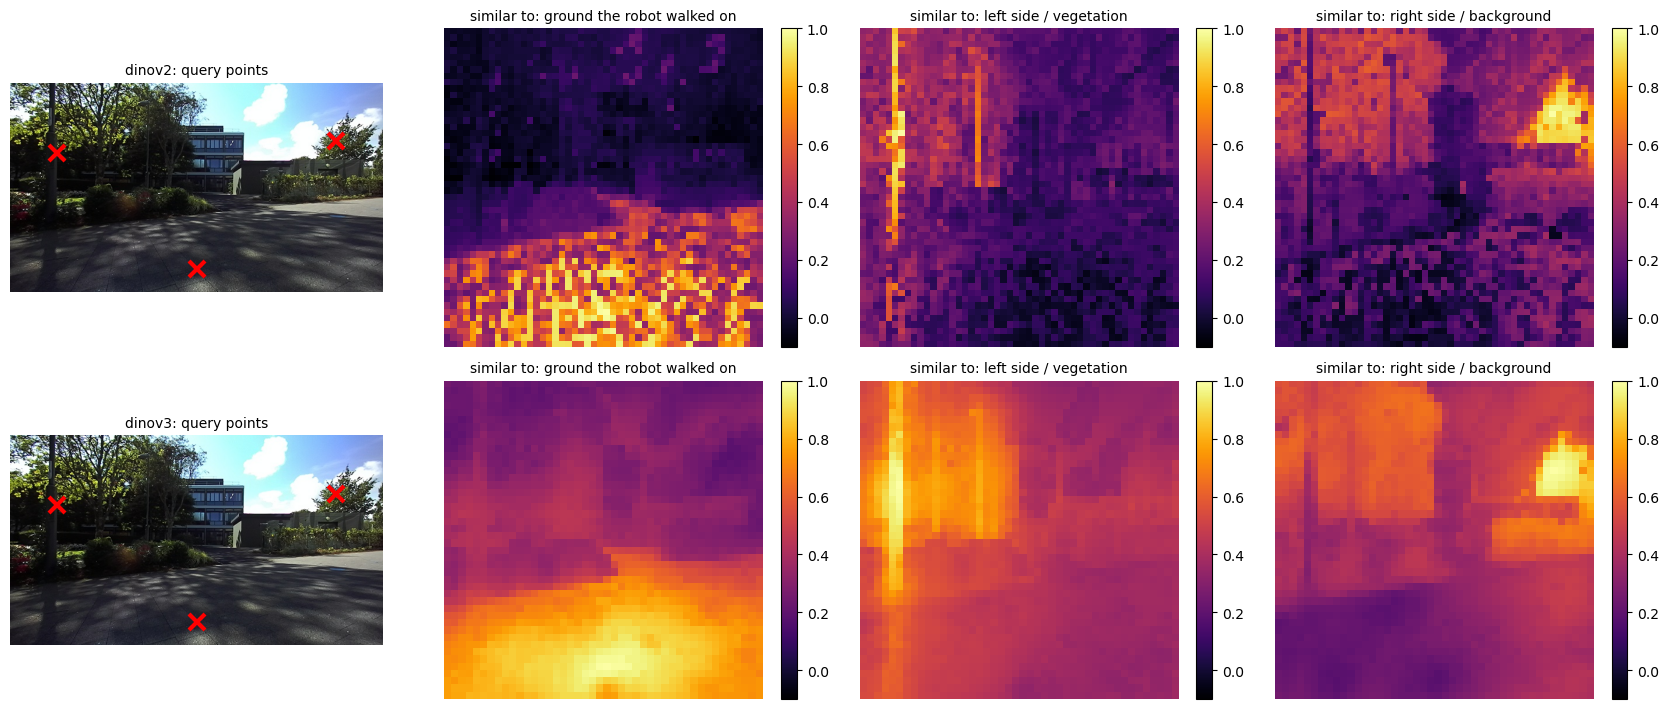

In [69]:
# (x, y, label) in ORIGINAL image coordinates
POINTS = [
    (320, 320, 'ground the robot walked on'),
    (80,  120, 'left side / vegetation'),
    (560, 100, 'right side / background'),
]

def similarity_map(name, x_original, y_original):
    h = hero[name]
    scale = h['model_input'] / hero_rgb.shape[1], h['model_input'] / hero_rgb.shape[0]
    col = int(x_original * scale[0]) // h['patch']
    row = int(y_original * scale[1]) // h['patch']
    col = min(max(col, 0), h['grid'] - 1); row = min(max(row, 0), h['grid'] - 1)

    flat = h['features'].reshape(-1, 384)
    reference = h['features'][row, col]
    unit = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + 1e-9)
    similarity = unit @ (reference / (np.linalg.norm(reference) + 1e-9))
    return similarity.reshape(h['grid'], h['grid'])

fig, axes = plt.subplots(len(BACKBONES), len(POINTS) + 1,
                         figsize=(4.2 * (len(POINTS) + 1), 3.6 * len(BACKBONES)))
for row, name in enumerate(BACKBONES):
    axes[row, 0].imshow(hero_rgb)
    for x, y, _ in POINTS:
        axes[row, 0].plot(x, y, marker='x', markersize=11, markeredgewidth=3, color='red')
    axes[row, 0].set_title(f'{name}: query points', fontsize=10)
    for column, (x, y, label) in enumerate(POINTS, start=1):
        image = axes[row, column].imshow(similarity_map(name, x, y),
                                         cmap='inferno', vmin=-0.1, vmax=1.0)
        axes[row, column].set_title(f'similar to: {label}', fontsize=10)
        fig.colorbar(image, ax=axes[row, column], fraction=0.045)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
save('figD_similarity_own.png')
plt.show()

## 7. Figure E --- traversability cost from our own-trained autoencoders

Now the actual output of the method, using the two autoencoders trained on our own data:
the continuous cost map, and the STEPP-style decision (green = traversable, red = not) at each
model's own median cost. Each backbone has its own cost scale, so each heat map is scaled to
its own range.

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figE_cost_own.png


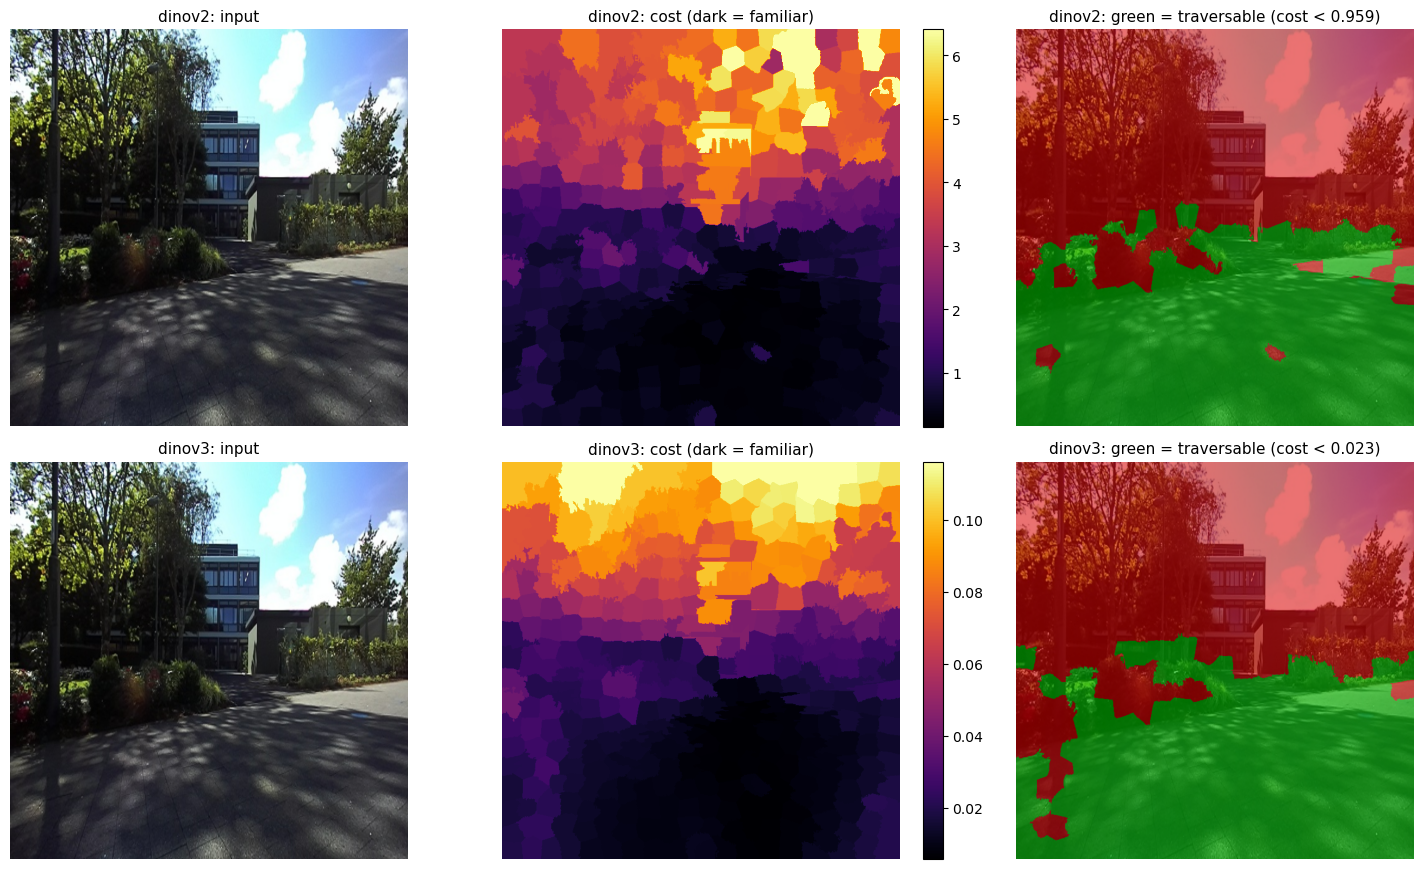

In [70]:
def cost_picture(name):
    h = hero[name]
    size = h['model_input']
    picture = np.zeros((size, size), np.float32)
    for sid, cost in zip(h['ids'], h['costs']):
        picture[h['segments'] == sid] = cost
    return picture

fig, axes = plt.subplots(len(BACKBONES), 3, figsize=(15, 4.4 * len(BACKBONES)))
for row, name in enumerate(BACKBONES):
    h = hero[name]
    cost = cost_picture(name)
    threshold = float(np.median(h['costs']))

    axes[row, 0].imshow(h['square'])
    axes[row, 0].set_title(f'{name}: input', fontsize=11)

    image = axes[row, 1].imshow(cost, cmap='inferno',
                                vmax=float(np.percentile(h['costs'], 97)))
    axes[row, 1].set_title(f'{name}: cost (dark = familiar)', fontsize=11)
    fig.colorbar(image, ax=axes[row, 1], fraction=0.045)

    decision = h['square'].copy()
    traversable = cost < threshold
    decision[traversable]  = (0.45 * decision[traversable]
                              + 0.55 * np.array([0, 200, 0])).astype(np.uint8)
    decision[~traversable] = (0.45 * decision[~traversable]
                              + 0.55 * np.array([220, 0, 0])).astype(np.uint8)
    axes[row, 2].imshow(decision)
    axes[row, 2].set_title(f'{name}: green = traversable (cost < {threshold:.3g})', fontsize=11)

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
save('figE_cost_own.png')
plt.show()

## 8. Figure F --- the patch-resolution difference, zoomed

DINOv2 uses 14-pixel patches (a 50×50 grid); DINOv3 uses 16-pixel patches (44×44). This is the
clearest single picture of what actually differs between the two backbones in this pipeline:
DINOv3 produces slightly coarser but visibly cleaner feature blocks.

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figF_patch_resolution.png


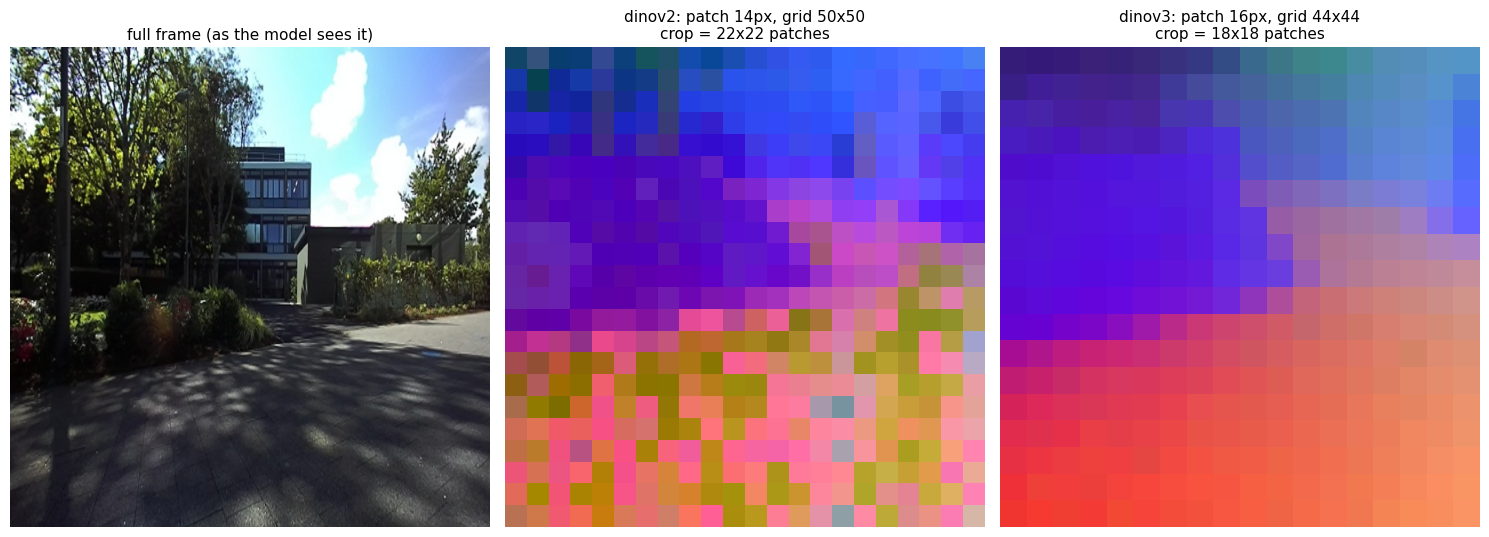

In [71]:
# a square crop around the lower middle of the image (where the path usually is)
CROP_FRACTION = 0.45      # take the middle 45% of the picture

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
axes[0].imshow(cv2.resize(hero_rgb, (hero['dinov2']['model_input'],) * 2))
axes[0].set_title('full frame (as the model sees it)', fontsize=11)

for column, name in enumerate(BACKBONES, start=1):
    h = hero[name]
    colours, _ = pca_colours(h['features'].reshape(-1, 384))
    picture = colours.reshape(h['grid'], h['grid'], 3)

    # crop the centre-bottom region and blow it up so individual patches are visible
    g = h['grid']
    half = int(g * CROP_FRACTION / 2)
    r0, c0 = int(g * 0.62) - half, g // 2 - half
    r0 = max(0, min(r0, g - 2 * half)); c0 = max(0, min(c0, g - 2 * half))
    crop = picture[r0:r0 + 2 * half, c0:c0 + 2 * half]

    axes[column].imshow(crop, interpolation='nearest')
    axes[column].set_title(f'{name}: patch {h["patch"]}px, grid {g}x{g}\n'
                           f'crop = {crop.shape[0]}x{crop.shape[1]} patches', fontsize=11)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
save('figF_patch_resolution.png')
plt.show()

## 9. Figure G --- feature statistics

This is the chart that explains why the two models' reconstruction losses and cost thresholds
must never be compared directly: DINOv3's feature values are numerically much smaller, so its
squared-error loss is automatically smaller too, regardless of quality.

Statistics are taken from the cached training features of the whole dataset, not just one frame.

dinov2: 139,506 vectors | mean +0.0424 | std 2.3309
dinov3: 139,523 vectors | mean +0.0004 | std 0.4078
saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures\figG_feature_statistics.png


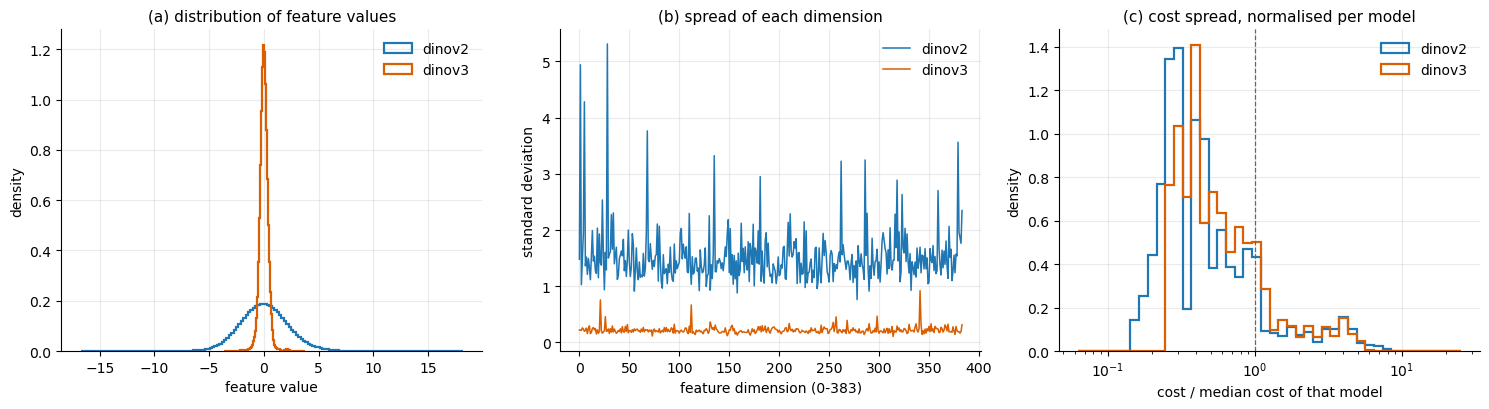


DINOv2 feature spread is 5.7x larger than DINOv3.
A squared-error loss therefore differs by roughly that factor squared, about 33x, for reasons that have nothing to do with quality.


In [72]:
FEATURE_DIR = OWN_OUT / 'features'

training_features = {}
for name in BACKBONES:
    files = sorted(FEATURE_DIR.glob(f'{name}_*.npy'))
    if files:
        stacked = np.concatenate([np.load(f) for f in files], axis=0)
    else:                                   # fall back to this frame only
        stacked = hero[name]['vectors']
        print(f'({name}: cached features not found, using the hero frame instead)')
    training_features[name] = stacked
    print(f'{name}: {stacked.shape[0]:,} vectors | mean {stacked.mean():+.4f} '
          f'| std {stacked.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) distribution of feature values
for name in BACKBONES:
    sample = training_features[name]
    sample = sample[np.random.RandomState(0).choice(len(sample), min(20000, len(sample)),
                                                    replace=False)]
    axes[0].hist(sample.ravel(), bins=160, histtype='step', linewidth=1.6,
                 density=True, color=COLOUR[name], label=name)
axes[0].set_xlabel('feature value'); axes[0].set_ylabel('density')
axes[0].set_title('(a) distribution of feature values', fontsize=11)
axes[0].legend(frameon=False); axes[0].grid(alpha=0.25)

# (b) per-dimension standard deviation
for name in BACKBONES:
    axes[1].plot(training_features[name].std(axis=0), linewidth=1.1,
                 color=COLOUR[name], label=name)
axes[1].set_xlabel('feature dimension (0-383)'); axes[1].set_ylabel('standard deviation')
axes[1].set_title('(b) spread of each dimension', fontsize=11)
axes[1].legend(frameon=False); axes[1].grid(alpha=0.25)

# (c) cost per superpixel, each model divided by ITS OWN median.
# Without this normalisation the two histograms sit on completely different ranges
# and cannot be drawn on one axis; dividing by the median compares their SHAPE.
bins = np.logspace(-1.2, 1.4, 45)
for name in BACKBONES:
    costs = hero[name]['costs']
    axes[2].hist(costs / np.median(costs), bins=bins, histtype='step', linewidth=1.6,
                 density=True, color=COLOUR[name], label=name)
axes[2].set_xscale('log')
axes[2].axvline(1.0, color='0.4', linestyle='--', linewidth=0.9)
axes[2].set_xlabel('cost / median cost of that model')
axes[2].set_ylabel('density')
axes[2].set_title('(c) cost spread, normalised per model', fontsize=11)
axes[2].legend(frameon=False); axes[2].grid(alpha=0.25)

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save('figG_feature_statistics.png')
plt.show()

ratio = training_features['dinov2'].std() / training_features['dinov3'].std()
print(f'\nDINOv2 feature spread is {ratio:.1f}x larger than DINOv3.')
print('A squared-error loss therefore differs by roughly that factor squared, '
      f'about {ratio**2:.0f}x, for reasons that have nothing to do with quality.')

## 10. What was produced

In [73]:
print('figures in', FIG_DIR, '\n')
for path in sorted(FIG_DIR.glob('*.png')):
    print(f'  {path.name:<38}{path.stat().st_size / 1024:8.0f} KB')

print('\nSuggested use in the paper:')
print('  figA  - one-figure summary of the whole method on our own robot')
print('  figB  - explains the superpixel averaging step')
print('  figC  - shows the backbones are consistent across places')
print('  figD  - shows WHY the method works (similar ground looks similar)')
print('  figE  - the actual traversability output of our own-trained models')
print('  figF  - the clearest visual of the DINOv2 vs DINOv3 difference')
print('  figG  - justifies never comparing the two models\' losses directly')

figures in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\paper_figures 

  figA_pipeline_own.png                     1808 KB
  figB_segment_average_own.png              2493 KB
  figC_features_across_frames.png           2618 KB
  figD_similarity_own.png                   1255 KB
  figE_cost_own.png                         3493 KB
  figF_patch_resolution.png                 1251 KB
  figG_feature_statistics.png                200 KB

Suggested use in the paper:
  figA  - one-figure summary of the whole method on our own robot
  figB  - explains the superpixel averaging step
  figC  - shows the backbones are consistent across places
  figD  - shows WHY the method works (similar ground looks similar)
  figE  - the actual traversability output of our own-trained models
  figF  - the clearest visual of the DINOv2 vs DINOv3 difference
  figG  - justifies never comparing the two models' losses directly
